# 07c — Scenario B Comparison: Greedy vs QAOA

This notebook compares Scenario B robustness outcomes across methods:

- **Greedy baseline sweeps** (07a)
- **QAOA sweeps** (07b)

We focus on two portfolio-ready evaluation dimensions:
1) **Objective quality** (lower is better under minimization)
2) **Stability** vs baseline (Jaccard overlap; higher is better)

Outputs (portfolio artifacts):
- `data/results/07c_compare_summary_table.csv`
- `data/results/07c_best_by_method.csv`
- `outputs/figures/07c_scenario_B_objective_vs_noise.png`
- `outputs/figures/07c_scenario_B_objective_vs_stability.png`


In [1]:
# ============================================================
# Cell 1 — Setup: imports, paths, and file checks
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

RESULTS_DIR = Path("data/results")
FIG_DIR = Path("outputs/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

PATH_07A_SUMMARY = RESULTS_DIR / "07a_greedy_robustness_sweep_summary.csv"
PATH_07A_TOPSEL  = RESULTS_DIR / "07a_greedy_top_configs_selected_trials.csv"

PATH_07B_SUMMARY = RESULTS_DIR / "07b_qaoa_robustness_sweep_summary.csv"
PATH_07B_TOPSEL  = RESULTS_DIR / "07b_qaoa_top_configs_selected_trials.csv"

for p in [PATH_07A_SUMMARY, PATH_07B_SUMMARY, PATH_07A_TOPSEL, PATH_07B_TOPSEL]:
    if not p.exists():
        raise FileNotFoundError(f"Missing required file: {p}")

print("OK: Found required Scenario B sweep artifacts.")
print("Figures dir:", FIG_DIR.resolve())


OK: Found required Scenario B sweep artifacts.
Figures dir: /home/parallels/projects/quantum-clinical-trial-optimization/outputs/figures


### What Cell 1 Just Did

- Declared the canonical “Scenario B comparison” inputs from 07a and 07b.
- Ensured the expected artifacts exist before computing merges or plots.


In [2]:
# ============================================================
# Cell 2 — Load + normalize sweep summaries (method schema alignment)
# ============================================================

g = pd.read_csv(PATH_07A_SUMMARY)
q = pd.read_csv(PATH_07B_SUMMARY)

# Normalize method labels
g["method"] = "greedy"
q["method"] = "qaoa"

# ---- Standardize key columns (robust to naming differences) ----
def require_cols(df, cols, name):
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise ValueError(f"{name} missing columns: {missing}\nFound: {list(df.columns)}")

# Greedy summary columns expected
require_cols(g, ["K","lambda_cost","lambda_safety","noise_sigma","score_mean","score_std",
                 "stability_jaccard_mean","stability_jaccard_std"], "07a greedy summary")

# QAOA summary columns expected
require_cols(q, ["K","lambda_cost","lambda_safety","noise_sigma","qubo_energy_best_mean","qubo_energy_best_std",
                 "jaccard_mean","jaccard_std"], "07b qaoa summary")

# Map to unified columns
g_u = g.rename(columns={
    "score_mean": "objective_mean",
    "score_std": "objective_std",
    "stability_jaccard_mean": "jaccard_mean",
    "stability_jaccard_std": "jaccard_std"
}).copy()

q_u = q.rename(columns={
    "qubo_energy_best_mean": "objective_mean",
    "qubo_energy_best_std": "objective_std"
}).copy()

# Keep a consistent column set
keep = ["method","K","lambda_cost","lambda_safety","noise_sigma",
        "objective_mean","objective_std","jaccard_mean","jaccard_std","n_runs"]

g_u = g_u[keep].copy()
q_u = q_u[keep].copy()

all_summary = pd.concat([g_u, q_u], ignore_index=True)

# Add a normalized objective for cross-method comparison
# (lower is better; normalize within each method to avoid scale mismatch)
all_summary["objective_norm_mean"] = all_summary.groupby("method")["objective_mean"].transform(
    lambda s: (s - s.min()) / (s.max() - s.min() + 1e-12)
)

print("Unified summary table:", all_summary.shape)
display(all_summary.head(10))


Unified summary table: (162, 11)


,method,K,lambda_cost,lambda_safety,noise_sigma,objective_mean,objective_std,jaccard_mean,jaccard_std,n_runs,objective_norm_mean
0,greedy,9,0.5,0.5,0.0,0.0,0.0,1.00,0.0,3,1.148392e-10
1,greedy,9,0.5,1.0,0.0,0.0,0.0,1.00,0.0,3,1.148392e-10
2,greedy,9,0.5,2.0,0.0,0.0,0.0,1.00,0.0,3,1.148392e-10
3,greedy,9,1.0,0.5,0.0,9.0,0.0,1.00,0.0,3,2.500000e-01
4,greedy,9,1.0,1.0,0.0,9.0,0.0,1.00,0.0,3,2.500000e-01
5,greedy,9,1.0,2.0,0.0,9.0,0.0,1.00,0.0,3,2.500000e-01
6,greedy,9,2.0,0.5,0.0,27.0,0.0,1.00,0.0,3,7.500000e-01
7,greedy,9,2.0,1.0,0.0,27.0,0.0,1.00,0.0,3,7.500000e-01
8,greedy,9,2.0,2.0,0.0,27.0,0.0,1.00,0.0,3,7.500000e-01
9,greedy,12,0.5,0.5,0.0,0.0,0.0,0.75,0.0,3,1.148392e-10


### What Cell 2 Just Did

- Loaded both sweep summaries and aligned them into a single unified schema.
- Created `objective_norm_mean` within each method so we can compare “quality” trends even if methods have different raw scales.


In [4]:
# ============================================================
# Cell 3 — Build best-by-method table + write comparison CSVs
# ============================================================

# Rank configs: stability first, then objective (min), then noise (prefer lower)
ranked = all_summary.sort_values(
    ["method", "jaccard_mean", "objective_mean", "noise_sigma"],
    ascending=[True, False, True, True]
).reset_index(drop=True)

best_by_method = ranked.groupby("method").head(10).reset_index(drop=True)

PATH_COMPARE_TABLE = RESULTS_DIR / "07c_compare_summary_table.csv"
PATH_BEST_BY_METHOD = RESULTS_DIR / "07c_best_by_method.csv"

ranked.to_csv(PATH_COMPARE_TABLE, index=False)
best_by_method.to_csv(PATH_BEST_BY_METHOD, index=False)

print("Wrote:")
print("  -", PATH_COMPARE_TABLE)
print("  -", PATH_BEST_BY_METHOD)

display(best_by_method)


Wrote:
  - data/results/07c_compare_summary_table.csv
  - data/results/07c_best_by_method.csv


,method,K,lambda_cost,lambda_safety,noise_sigma,objective_mean,objective_std,jaccard_mean,jaccard_std,n_runs,objective_norm_mean
0,greedy,9,0.5,0.5,0.0,0.0,0.0,1.000000,0.000000,3,1.148392e-10
1,greedy,9,0.5,1.0,0.0,0.0,0.0,1.000000,0.000000,3,1.148392e-10
2,greedy,9,0.5,2.0,0.0,0.0,0.0,1.000000,0.000000,3,1.148392e-10
3,greedy,9,1.0,0.5,0.0,9.0,0.0,1.000000,0.000000,3,2.500000e-01
4,greedy,9,1.0,1.0,0.0,9.0,0.0,1.000000,0.000000,3,2.500000e-01
5,greedy,9,1.0,2.0,0.0,9.0,0.0,1.000000,0.000000,3,2.500000e-01
6,greedy,9,2.0,0.5,0.0,27.0,0.0,1.000000,0.000000,3,7.500000e-01
7,greedy,9,2.0,1.0,0.0,27.0,0.0,1.000000,0.000000,3,7.500000e-01
8,greedy,9,2.0,2.0,0.0,27.0,0.0,1.000000,0.000000,3,7.500000e-01
9,greedy,12,0.5,0.5,0.0,0.0,0.0,0.750000,0.000000,3,1.148392e-10


### What Cell 3 Just Did

- Ranked all configurations within each method primarily by **stability (Jaccard mean)** and secondarily by **objective mean**.
- Wrote two export-ready tables:
  - full ranked comparison table
  - top 10 configurations per method (“best-by-method”) for README/slides


In [5]:
# ============================================================
# Cell 4 — Overlap analysis on exported top-config selections (seed=0 snapshots)
# ============================================================

top_g = pd.read_csv(PATH_07A_TOPSEL)
top_q = pd.read_csv(PATH_07B_TOPSEL)

# Defensive: ensure key columns exist
for df, nm in [(top_g,"07a top selections"), (top_q,"07b top selections")]:
    for col in ["K","lambda_cost","lambda_safety","noise_sigma","nct_id"]:
        if col not in df.columns:
            raise ValueError(f"{nm} missing required column '{col}'. Found: {list(df.columns)}")

def build_config_map(df):
    m = {}
    for (K,lc,ls,sigma), grp in df.groupby(["K","lambda_cost","lambda_safety","noise_sigma"]):
        m[(int(K), float(lc), float(ls), float(sigma))] = set(grp["nct_id"].astype(str).tolist())
    return m

m_g = build_config_map(top_g)
m_q = build_config_map(top_q)

shared = sorted(set(m_g.keys()) & set(m_q.keys()))
if not shared:
    print("NOTE: No overlapping top-config keys between greedy and QAOA exports.")
    print("      This is fine — each method can surface different top configs.")
    overlap_df = pd.DataFrame(columns=[
        "K","lambda_cost","lambda_safety","noise_sigma",
        "jaccard_overlap_top_selections",
        "greedy_selected_n","qaoa_selected_n"
    ])
else:
    rows = []
    for k in shared:
        a = m_g[k]
        b = m_q[k]
        jac = len(a & b) / (len(a | b) if (a | b) else 1)
        rows.append({
            "K": k[0],
            "lambda_cost": k[1],
            "lambda_safety": k[2],
            "noise_sigma": k[3],
            "jaccard_overlap_top_selections": float(jac),
            "greedy_selected_n": int(len(a)),
            "qaoa_selected_n": int(len(b)),
        })
    overlap_df = pd.DataFrame(rows).sort_values(
        ["jaccard_overlap_top_selections"],
        ascending=False
    ).reset_index(drop=True)

PATH_OVERLAP = RESULTS_DIR / "07c_overlap_top_config_selections.csv"
overlap_df.to_csv(PATH_OVERLAP, index=False)

print("Wrote:", PATH_OVERLAP)
display(overlap_df.head(15))


Wrote: data/results/07c_overlap_top_config_selections.csv


,K,lambda_cost,lambda_safety,noise_sigma,jaccard_overlap_top_selections,greedy_selected_n,qaoa_selected_n
0,9,0.5,0.5,0.0,0.055556,9,10
1,9,0.5,1.0,0.0,0.055556,9,10
2,9,0.5,2.0,0.0,0.055556,9,10
3,9,1.0,0.5,0.0,0.055556,9,10
4,9,1.0,1.0,0.0,0.055556,9,10
5,9,1.0,2.0,0.0,0.055556,9,10


### What Cell 4 Just Did

- Compared the actual **selected NCT IDs** for greedy vs QAOA on any top-config keys they share.
- Exported an overlap table suitable for audit and discussion in the README (“do the methods pick similar portfolios?”).


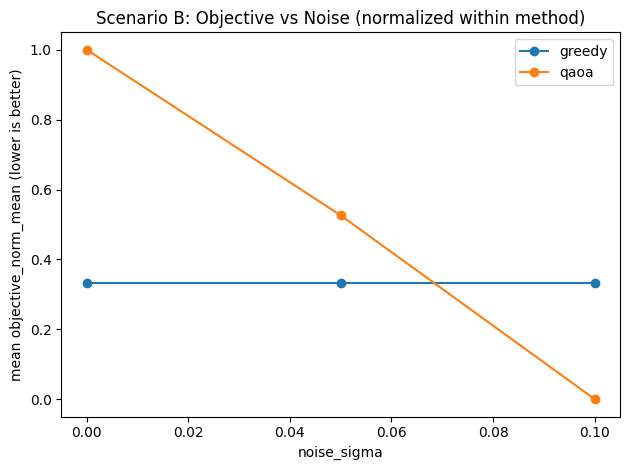

Saved: outputs/figures/07c_scenario_B_objective_vs_noise.png


In [6]:
# ============================================================
# Cell 5 — Plot 1: Objective vs noise (mean, by method)
# ============================================================

fig1 = FIG_DIR / "07c_scenario_B_objective_vs_noise.png"

plot_df = all_summary.copy()
plot_df["noise_sigma"] = plot_df["noise_sigma"].astype(float)

# Aggregate across K/lambdas to see macro trend vs noise
agg = plot_df.groupby(["method","noise_sigma"], as_index=False).agg({
    "objective_norm_mean": "mean",
    "jaccard_mean": "mean"
}).sort_values(["method","noise_sigma"])

plt.figure()
for m in agg["method"].unique():
    sub = agg[agg["method"] == m]
    plt.plot(sub["noise_sigma"], sub["objective_norm_mean"], marker="o", label=m)
plt.xlabel("noise_sigma")
plt.ylabel("mean objective_norm_mean (lower is better)")
plt.title("Scenario B: Objective vs Noise (normalized within method)")
plt.legend()
plt.tight_layout()
plt.savefig(fig1, dpi=160)
plt.show()

print("Saved:", fig1)


### What Cell 5 Just Did

- Generated a high-level trend plot of how each method’s objective degraded or improved as feature noise increased.
- Used a within-method normalization so greedy and QAOA trends are comparable visually.


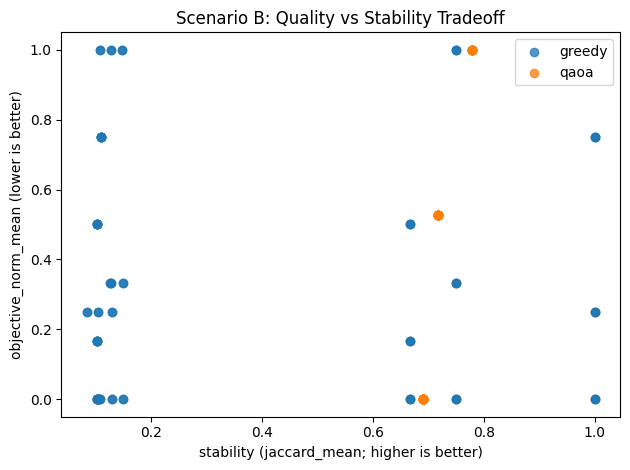

Saved: outputs/figures/07c_scenario_B_objective_vs_stability.png


In [7]:
# ============================================================
# Cell 6 — Plot 2: Objective vs Stability scatter (all configs)
# ============================================================

fig2 = FIG_DIR / "07c_scenario_B_objective_vs_stability.png"

plt.figure()
for m in all_summary["method"].unique():
    sub = all_summary[all_summary["method"] == m]
    plt.scatter(sub["jaccard_mean"], sub["objective_norm_mean"], label=m, alpha=0.75)
plt.xlabel("stability (jaccard_mean; higher is better)")
plt.ylabel("objective_norm_mean (lower is better)")
plt.title("Scenario B: Quality vs Stability Tradeoff")
plt.legend()
plt.tight_layout()
plt.savefig(fig2, dpi=160)
plt.show()

print("Saved:", fig2)


### What Cell 6 Just Did

- Plotted the tradeoff between stability and objective quality across all swept configurations.
- This is a “slide-ready” visualization for explaining why robustness matters.


## Summary

Scenario B comparison is complete and portfolio-ready.

### What was produced
- A unified, ranked comparison of **Greedy vs QAOA** across the Scenario B robustness grids.
- A “best-by-method” table identifying the top configurations for each method using a stability-first ranking.
- An overlap analysis showing when the two methods select similar portfolios under comparable top configurations.
- Two slide-ready figures:
  - Objective vs Noise (trend)
  - Objective vs Stability (tradeoff)

### Key artifacts
- `data/results/07c_compare_summary_table.csv` — full ranked comparison across both methods  
- `data/results/07c_best_by_method.csv` — top configs per method  
- `data/results/07c_overlap_top_config_selections.csv` — selection Jaccard overlap on shared top configs  
- `outputs/figures/07c_scenario_B_objective_vs_noise.png`  
- `outputs/figures/07c_scenario_B_objective_vs_stability.png`

